In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, GridSearchCV,train_test_split, validation_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import  classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


**Introduction:**

I will add new information in soon

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
# importing dataset
df = pd.read_csv('/kaggle/input/loancsv/loan.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# we are looking what has it in this data
def check_data(df):
    print('HEAD {0}'.format(df.head()))
    print("-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")
    print('TAIL {0}'.format(df.tail()))
    print('SHAPE: {0}'.format(df.shape))
    print("-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")
    print('INFO: {0}'.format(df.info()))
    print("-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")
    print('COLUMNS: {0}'.format(df.columns))
    print("-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")
    print('DESCRIBE {0}'.format(df.describe().T))
    print("-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")
check_data(df)

HEAD     Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1

In [5]:
# How much features and rows
df.shape

(614, 13)

In [6]:
# istatistical information
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [7]:
# we divided columns with type and droped useless columns
cat_cols = [col for col in df.columns if df[col].dtypes == 'O' and 'Loan_ID' not in col]
num_cols = [col for col in df.columns if df[col].dtypes != 'O' and 'Credit_History' not in col]

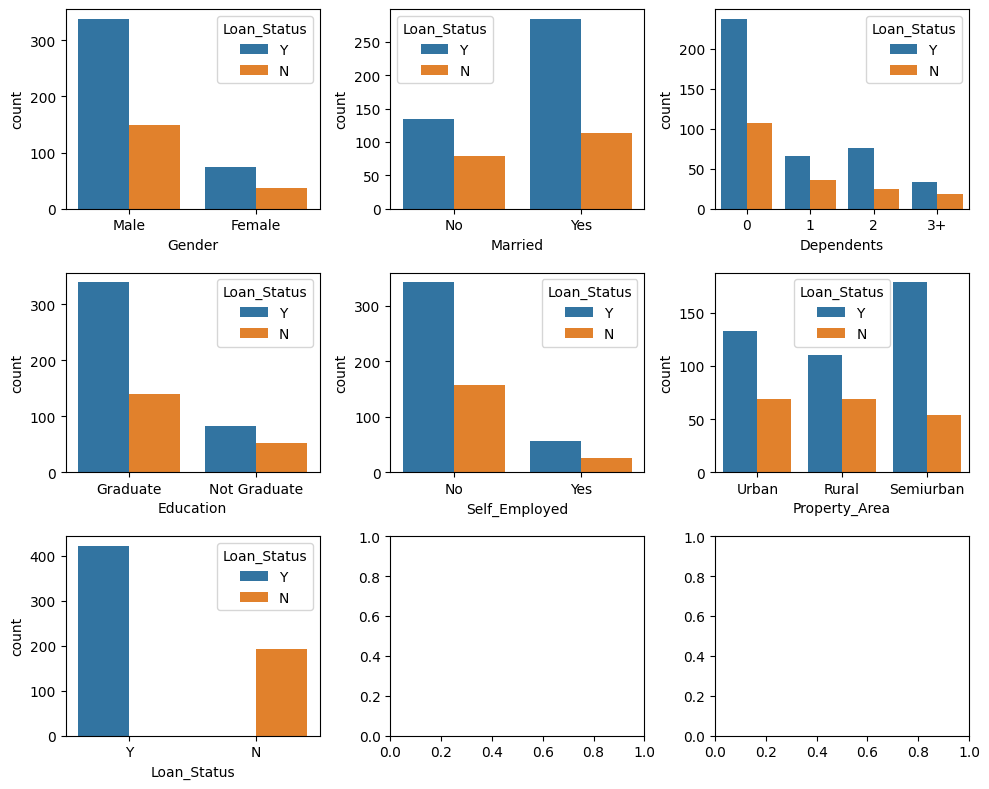

In [8]:
# visualization categorical columns cross with Loan Status
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10,8))
axs = axs.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, hue='Loan_Status',ax=axs[i])
fig.tight_layout()
plt.show()

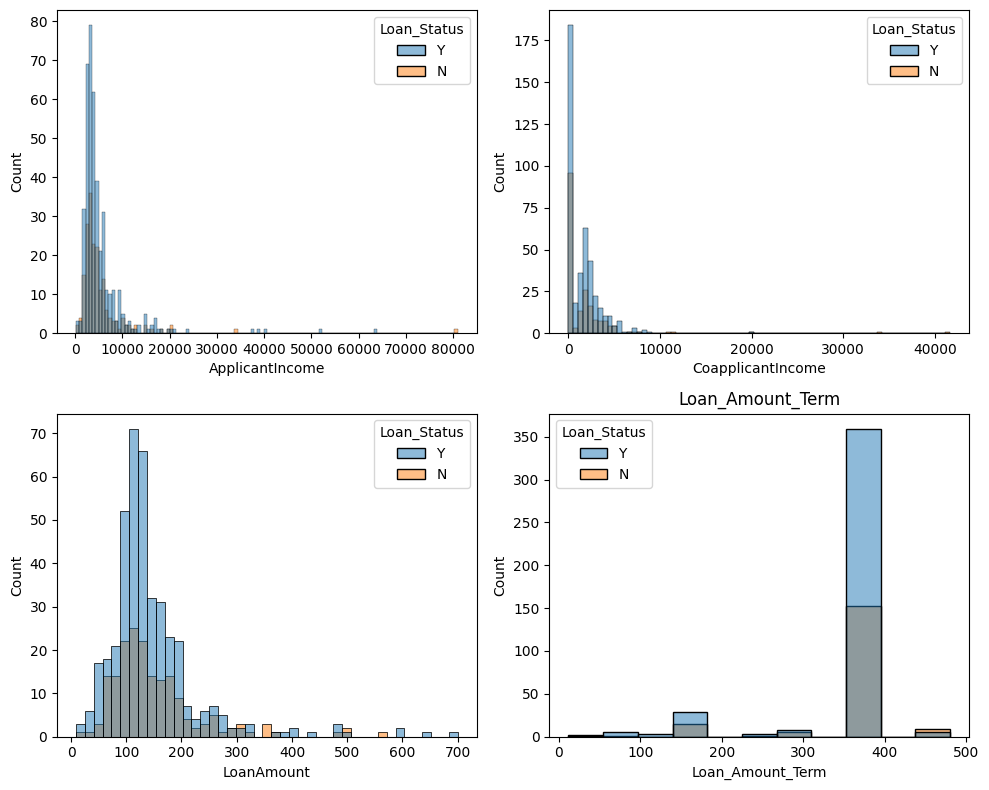

In [9]:
fig, axs = plt.subplots(nrows=2,ncols=2, figsize=(10,8))
axs = axs.flatten()
for i,col in enumerate(num_cols):
    sns.histplot(x= col, data= df,hue= 'Loan_Status', ax=axs[i],kde=False)
    plt.title(col)
fig.tight_layout()
#fig.delaxes(axs[4])
plt.show()

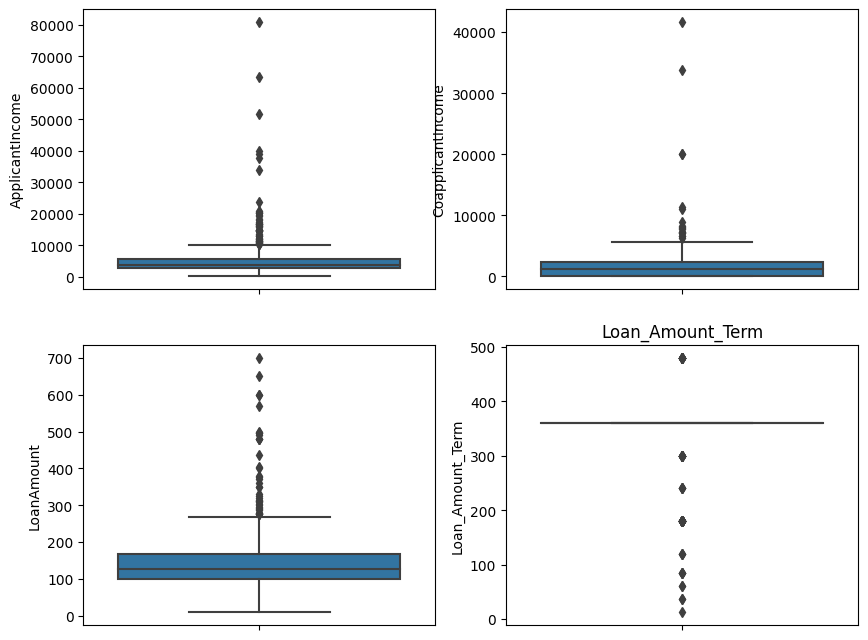

In [10]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
axs = axs.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=col,data=df,ax=axs[i])
    plt.title(col)
plt.show()

In [11]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
# we fill NaN variable
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df.fillna(df.groupby(['Gender','Married','Education'])['Loan_Amount_Term'].transform('median'))
df.loc[(df['LoanAmount'] > df['LoanAmount'].mean()) & (df['Credit_History'] == 0),'Credit_History'] = 1

In [ ]:
null_col_cat = [col for col in df.columns if df['Dependents'].isnull().sum() > 1 and df[col].dtypes == 'O' and 'Loan_ID' not in col]
null_col_num = [col for col in df.columns if df['Dependents'].isnull().sum() > 1 and df[col].dtypes != 'O']

In [ ]:
# that can bu use for cat_cols beacause cat cols can fill with mode 
def null_col_fill(null_cols):
    for col in null_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
null_col_fill(null_col_cat)

In [ ]:
fig, axs = plt.subplots(figsize=(8,6))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', data=df)
plt.show()

In [ ]:
fig, axs = plt.subplots(figsize=(8,6))
sns.scatterplot(x='CoapplicantIncome',y='LoanAmount', hue='Loan_Status',data=df)
plt.show()

In [ ]:
df['Total_Income'] = df['CoapplicantIncome'] + df['ApplicantIncome']
df['Remainder_Loan'] = df['LoanAmount'] - df['Loan_Amount_Term']
# df['Coapp_App_Minus'] = df['ApplicantIncome'] - df['CoapplicantIncome']
# Payment Duration
# df['Payment Duration'] = df['LoanAmount'] / df['Loan_Amount_Term']

In [ ]:
# Total Income / Loan Amount
(round(df['LoanAmount'] / df['Total_Income'],2) * 100).head()

In [ ]:
# loan Amout 
fix, axs = plt.subplots(nrows=2,ncols=4,figsize=(15,12))
axs = axs.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='LoanAmount',hue='Loan_Status', data=df, ax=axs[i])
fig.tight_layout()
plt.show()

In [ ]:
# Total Income
fix, axs = plt.subplots(nrows=2,ncols=4,figsize=(15,12))
axs = axs.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='Total_Income',hue='Loan_Status', data=df, ax=axs[i])
fig.tight_layout()
plt.show()

In [ ]:
corr = df.corr()
sns.set(rc={'figure.figsize':(10,8)})
sns.heatmap(corr,linewidths=.5, annot=True, cmap="YlGnBu").set_title('Corr Map')
plt.show()

In [ ]:
sns.pairplot(df[num_cols])
plt.show()

In [ ]:
# Preparing For Machine Learning
df.head()

In [ ]:
cat_cols = [col for col in df.columns if df[col].dtypes == 'O' and df[col].nunique()  == 2]
num_cols = [col for col in df.columns if df[col].dtypes != 'O' and col not in ['Loan_ID','Credit_History']]

In [ ]:
df[num_cols] = RobustScaler().fit_transform(df[num_cols])

In [ ]:
df[cat_cols] = pd.get_dummies(df[cat_cols],drop_first=True)

In [ ]:
def one_hot_encoder(dataframe, categorical_col, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns = categorical_col, drop_first = drop_first)
    return dataframe
ohe_cols = [col for col in df.columns if df[col].dtypes == 'O' and 10 >= df[col].nunique() > 2]
df = one_hot_encoder(df,ohe_cols)
df.head()

In [ ]:
df.drop(['Loan_ID'],axis=1,inplace=True)
df.dropna(inplace=True)

In [ ]:
X, y = df.iloc[:, df.columns != 'Loan_Status'], df.iloc[:, df.columns == 'Loan_Status']

In [ ]:
rf_model = RandomForestClassifier().fit(X,y.values.ravel())

In [ ]:
scoring = ['accuracy','f1','roc_auc','precision','recall']

In [ ]:
cv_results = cross_validate(rf_model,X,y.values.ravel(),n_jobs=-1, cv=5,scoring=scoring)

In [ ]:
for scor in scoring:
    print(scor,':',round(cv_results['test_'+scor].mean(),2))

In [ ]:
rf_params = {'max_depth':[2,4,7,10,None],
            'max_features':[2,3,5,'sqrt'],
            'min_samples_split':[2,4,5,7]}

In [ ]:
rf_best_gird = GridSearchCV(rf_model,rf_params,cv=5,n_jobs=-1).fit(X,y.values.ravel())

In [ ]:
rf_best_gird.best_params_

In [ ]:
rf_final = rf_model.set_params(**rf_best_gird.best_params_,random_state=17).fit(X,y)

In [ ]:
rf_cv_final = cross_validate(rf_final,X,y.values.ravel(),cv=5,n_jobs=-1,scoring=scoring)

In [ ]:
for scor in scoring:
    print(scor,':',round(rf_cv_final['test_'+scor].mean(),2))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y.values.ravel(),test_size=0.3,random_state=17)

In [ ]:
y_pred = rf_final.predict(X_test)

In [ ]:
fig, axs = plt.subplots(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='.2f',ax=axs)
plt.show()

In [ ]:
def plot_importance(model, features, num=len(X),save=False):
    feature_imp = pd.DataFrame({'Value':model.feature_importances_, 'Features':features.columns})
    plt.figure(figsize=(6,4))
    sns.set(font_scale=1)
    sns.barplot(x='Value',y='Features',data=feature_imp.sort_values(by='Value',ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importance.png')

In [ ]:
plot_importance(rf_final,X)

In [ ]:
lgbm_model = LGBMClassifier().fit(X,y)

In [ ]:
lgbm_cv = cross_validate(lgbm_model,X,y.values.ravel(),cv=5,n_jobs=-1,scoring=scoring)

In [ ]:
for scor in scoring:
    print(scor,':',round(lgbm_cv['test_'+scor].mean(),2))

In [ ]:
lgmb_params = {'learning_rate':[0.01,0.1],
              'max_depth':[-1,1,3,5],
              'n_estimators': [100,200,400]}

In [ ]:
lgmb_grid_best = GridSearchCV(lgbm_model, lgmb_params, cv=5, verbose=True).fit(X,y.values.ravel())

In [ ]:
lgmb_final = lgbm_model.set_params(**lgmb_grid_best.best_params_).fit(X,y.values.ravel())

In [ ]:
lgmb_cv_final = cross_validate(lgmb_final,X,y.values.ravel(),cv=5,n_jobs=-1,scoring=scoring)

In [ ]:
for scor in scoring:
    print(scor, ':', lgmb_cv_final['test_'+scor].mean())

In [ ]:
y_pred_lgbm = lgmb_final.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred_lgbm))

In [ ]:
sns.heatmap(confusion_matrix(y_pred,y_pred_lgbm),annot=True,fmt='.2f')
plt.show()